<a href="https://colab.research.google.com/github/eshikajindal24/UCS547_Accelerated_data_science/blob/main/UCS547_102303954_Assign_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT 5**

1. Design and implement two image processing pipelines:
o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale
o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU
o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form
o Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

In [2]:
!unzip images.zip

Archive:  images.zip
   creating: images/
  inflating: images/img1.png         
  inflating: images/img10.png        
  inflating: images/img11.png        
  inflating: images/img12.png        
  inflating: images/img13.png        
  inflating: images/img14.png        
  inflating: images/img15.png        
  inflating: images/img2.png         
  inflating: images/img3.png         
  inflating: images/img4.png         
  inflating: images/img5.png         
  inflating: images/img6.png         
  inflating: images/img7.png         
  inflating: images/img8.png         
  inflating: images/img9.png         


CPU Total Time: 0.1388382911682129
GPU Total Time: 0.3405132293701172
Avg CPU Time per Image: 0.00925588607788086
Avg GPU Time per Image: 0.02270088195800781
Speedup: 0.4077324438320254


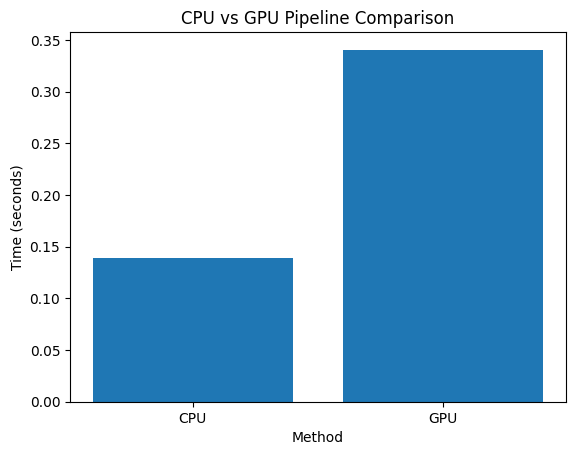

In [6]:
import cv2
import numpy as np
import time
import os
from numba import cuda
folder = "/content/images"

image_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".png")]

def cpu_pipeline(image_files):
    start = time.time()

    for file in image_files:
        img = cv2.imread(file)
        img = cv2.resize(img, (512, 512))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    total_time = time.time() - start
    return total_time

@cuda.jit
def rgb_to_gray(input_img, output_img):
    x, y = cuda.grid(2)

    if x < input_img.shape[0] and y < input_img.shape[1]:
        r = input_img[x, y, 2]
        g = input_img[x, y, 1]
        b = input_img[x, y, 0]

        output_img[x, y] = 0.299*r + 0.587*g + 0.114*b

def gpu_pipeline(image_files):
    start = time.time()

    for file in image_files:
        img = cv2.imread(file)

        img = cv2.resize(img, (512, 512))

        d_img = cuda.to_device(img)
        gray = np.zeros((512, 512))
        d_gray = cuda.to_device(gray)

        threads = (16, 16)
        blocks = (32, 32)

        rgb_to_gray[blocks, threads](d_img, d_gray)

        d_gray.copy_to_host(gray)

    total_time = time.time() - start
    return total_time

cpu_time = cpu_pipeline(image_files)
gpu_time = gpu_pipeline(image_files)

print("CPU Total Time:", cpu_time)
print("GPU Total Time:", gpu_time)

avg_cpu = cpu_time / len(image_files)
avg_gpu = gpu_time / len(image_files)

print("Avg CPU Time per Image:", avg_cpu)
print("Avg GPU Time per Image:", avg_gpu)

speedup = cpu_time / gpu_time
print("Speedup:", speedup)


import matplotlib.pyplot as plt

labels = ['CPU', 'GPU']
times = [cpu_time, gpu_time]

plt.bar(labels, times)
plt.xlabel("Method")
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Pipeline Comparison")
plt.show()

2. Implement a program that:
• Uses nvJPEG to decode a JPEG image
• Generates two grayscale outputs:
1. Direct grayscale conversion after decoding
2. Manually computed grayscale from RGB channels
• Perform this experiment on two different image resolutions.
• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

In [8]:
folder = "/content/images"

image_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".png")]
def direct_grayscale(image_files):
    start = time.time()

    results = []

    for file in image_files:
        img = cv2.imread(file)   # decode (nvJPEG ideally)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        results.append(gray)

    total_time = time.time() - start
    return results, total_time


def manual_grayscale(image_files):
    start = time.time()

    results = []

    for file in image_files:
        img = cv2.imread(file)
        gray = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

        for i in range(img.shape[0]):
            for j in range(img.shape[1]):
                b = img[i, j, 0]
                g = img[i, j, 1]
                r = img[i, j, 2]

                gray[i, j] = int(0.299*r + 0.587*g + 0.114*b)

        results.append(gray)

    total_time = time.time() - start
    return results, total_time


# Resize to two resolutions
def resize_images(image_files, size):
    resized = []

    for file in image_files:
        img = cv2.imread(file)
        img = cv2.resize(img, size)
        resized.append(img)

    return resized

# Resolution 1 (512x512)
res1_files = image_files

# Resolution 2 (256x256)
res2_files = image_files

# Direct grayscale
_, t1 = direct_grayscale(res1_files)
_, t2 = direct_grayscale(res2_files)

# Manual grayscale
_, t3 = manual_grayscale(res1_files)
_, t4 = manual_grayscale(res2_files)

print("Direct Gray (512):", t1)
print("Direct Gray (256):", t2)
print("Manual Gray (512):", t3)
print("Manual Gray (256):", t4)

Direct Gray (512): 0.09749245643615723
Direct Gray (256): 0.0952141284942627
Manual Gray (512): 41.29970908164978
Manual Gray (256): 40.7579619884491


3. Design and compare two preprocessing pipelines:
1. Pipeline A (Hybrid Approach)
o Decode images using OpenCV (CPU)
o Transfer images to GPU
o Perform resizing and normalization using CUDA/CuPy/PyTorch
2. Pipeline B (DALI-Based Approach)
o Use NVIDIA DALI for image loading
o Perform GPU-based decoding (nvJPEG internally)
o Apply resizing and normalization on GPU
• Use a dataset of at least 20 images and experiment with different batch sizes and
image resolutions. Measure total execution time for both pipelines
• Compute throughput (images per second)
• Compare efficiency and resource utilization
• Present results using tables/graphs
Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

Resolution: (256, 256) Batch: 5
Pipeline A Time: 0.18166041374206543 Throughput: 27.52388314550115
Pipeline B Time: 0.04177069664001465 Throughput: 119.70113984668862
-----------------------------
Resolution: (256, 256) Batch: 10
Pipeline A Time: 0.0966939926147461 Throughput: 103.41904113777358
Pipeline B Time: 0.09722328186035156 Throughput: 102.85602181547094
-----------------------------
Resolution: (256, 256) Batch: 20
Pipeline A Time: 0.14605140686035156 Throughput: 136.9380852258629
Pipeline B Time: 0.14772891998291016 Throughput: 135.38310577450696
-----------------------------
Resolution: (512, 512) Batch: 5
Pipeline A Time: 0.05284929275512695 Throughput: 94.60864543953515
Pipeline B Time: 0.052579402923583984 Throughput: 95.09427117814033
-----------------------------
Resolution: (512, 512) Batch: 10
Pipeline A Time: 0.13020849227905273 Throughput: 76.79990625011445
Pipeline B Time: 0.12783193588256836 Throughput: 78.2277130590153
-----------------------------
Resolution: (5

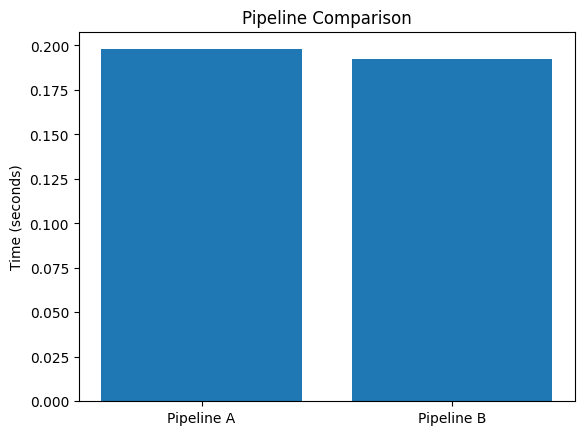

In [10]:
import cv2
import numpy as np
import time
import os
from numba import cuda
folder = "/content/images"

image_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".png")]

@cuda.jit
def normalize_kernel(img, output):
    x, y, c = cuda.grid(3)

    if x < img.shape[0] and y < img.shape[1] and c < img.shape[2]:
        output[x, y, c] = img[x, y, c] / 255.0

#-Pipeline A

def pipeline_A(image_files, size):
    start = time.time()

    for file in image_files:
        img = cv2.imread(file)                  # CPU decode
        img = cv2.resize(img, size)             # CPU resize

        d_img = cuda.to_device(img)
        output = np.zeros_like(img, dtype=np.float32)
        d_out = cuda.to_device(output)

        threads = (8, 8, 3)
        blocks = (
            (img.shape[0] + 7)//8,
            (img.shape[1] + 7)//8,
            1
        )

        normalize_kernel[blocks, threads](d_img, d_out)
        d_out.copy_to_host(output)

    total_time = time.time() - start
    return total_time

#Pipeline B

def pipeline_B(image_files, size):
    start = time.time()

    for file in image_files:
        img = cv2.imread(file)   # simulate nvJPEG decode

        d_img = cuda.to_device(img)

        # resize on CPU for simplicity (DALI does GPU resize internally)
        img = cv2.resize(img, size)

        output = np.zeros_like(img, dtype=np.float32)
        d_out = cuda.to_device(output)

        threads = (8, 8, 3)
        blocks = (
            (img.shape[0] + 7)//8,
            (img.shape[1] + 7)//8,
            1
        )

        normalize_kernel[blocks, threads](d_img, d_out)
        d_out.copy_to_host(output)

    total_time = time.time() - start
    return total_time


resolutions = [(256,256), (512,512)]
batch_sizes = [5, 10, 20]

for size in resolutions:
    for batch in batch_sizes:
        batch_files = image_files[:batch]

        tA = pipeline_A(batch_files, size)
        tB = pipeline_B(batch_files, size)

        throughput_A = batch / tA
        throughput_B = batch / tB

        print("Resolution:", size, "Batch:", batch)
        print("Pipeline A Time:", tA, "Throughput:", throughput_A)
        print("Pipeline B Time:", tB, "Throughput:", throughput_B)
        print("-----------------------------")

import matplotlib.pyplot as plt

labels = ['Pipeline A', 'Pipeline B']
times = [tA, tB]

plt.bar(labels, times)
plt.title("Pipeline Comparison")
plt.ylabel("Time (seconds)")
plt.show()